<a href="https://colab.research.google.com/github/saffarizadeh/INSY5378/blob/main/Timeseries_Forecasting_with_RNNs.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<img src="https://kambizsaffari.com/Logo/College_of_Business.cmyk-hz-lg.png" width="500px"/>

# *INSY 5378 - Advanced AI*

# **Timeseries Forecasting with RNNs**

Instructor: Dr. Kambiz Saffari

---

Note: You MUST read the chapter. Going through this notebook does not replace the value of reading the chapter.

Link to the chapter: https://deeplearningwithpython.io/chapters/chapter13_timeseries-forecasting/

> *Disclaimer: This notebook is a personal study guide created for educational purposes. It summarizes and references material from "Deep Learning with Python, Third Edition" by François Chollet and Matthew Watson (Manning Publications). All rights to the original content, including text, images, and code, belong to the respective authors and publisher. This notebook is not intended for commercial use or redistribution. Please support the authors by purchasing the book at Manning.*

In [ ]:
import os
os.environ["KERAS_BACKEND"] = "jax"

In [ ]:
!pip install keras keras-hub --upgrade -q

## Timeseries Forecasting

This chapter covers:

- An overview of machine learning for **timeseries**
- Understanding **recurrent neural networks** (RNNs)
- Applying RNNs to a **temperature forecasting** example
- Techniques for improving RNNs: **dropout**, **stacking**, and **bidirectional** layers

Timeseries data is everywhere: stock prices, weather measurements, electricity consumption, website traffic, sensor readings. What makes timeseries special is that **temporal order matters**: the sequence in which data points arrive carries critical information. This is fundamentally different from image classification or tabular data, where shuffling samples doesn't change the problem.

The most common timeseries task is **forecasting**: using the recent past to predict the near future.

---

**Key Terminology (Chapter 13 Glossary)**

| Term | Definition |
|------|------------|
| Timeseries | Data obtained via measurements at regular intervals (e.g., daily stock prices, hourly temperature) |
| Forecasting | Predicting what will happen next in a timeseries based on past observations |
| RNN (Recurrent Neural Network) | A neural network with an internal loop that processes sequences step-by-step, maintaining a *state* |
| SimpleRNN | The most basic RNN layer; suffers from the vanishing gradients problem on long sequences |
| LSTM (Long Short-Term Memory) | An RNN variant with a *carry track* that allows information to persist across many timesteps |
| GRU (Gated Recurrent Unit) | A streamlined alternative to LSTM, introduced by Cho et al. (2014) |
| Vanishing gradients | The problem where gradients shrink to near-zero across many timesteps, preventing the network from learning long-term dependencies |
| `return_sequences` | When `True`, an RNN layer outputs the full sequence; when `False` (default), it outputs only the last timestep |
| Recurrent dropout | Applying the same dropout mask at every timestep (rather than a random one) to properly regularize RNNs |
| Bidirectional RNN | An RNN that processes the input both forward and backward, then merges the representations |
| `timeseries_dataset_from_array()` | A Keras utility that creates sliding-window datasets from timeseries arrays |

## Different Kinds of Timeseries Tasks

While **forecasting** is the focus of this chapter, other important timeseries tasks include:

- **Anomaly detection**: Identifying unusual patterns in a data stream (e.g., fraud detection, network intrusion)
- **Classification**: Assigning labels to entire sequences (e.g., is a website visitor a bot or human?)
- **Event detection**: Identifying when a specific event occurs in a stream (e.g., hotword detection: "OK, Google")

## A Temperature Forecasting Example

Our task throughout this chapter: **predict the temperature 24 hours in the future**, given a timeseries of hourly measurements (atmospheric pressure, humidity, wind, etc.) recorded over the recent past.

We'll use a weather timeseries dataset recorded at the Max Planck Institute for Biogeochemistry in Jena, Germany. It contains 14 different weather quantities recorded every 10 minutes from 2009 to 2016.

In [ ]:
!wget https://s3.amazonaws.com/keras-datasets/jena_climate_2009_2016.csv.zip
!unzip jena_climate_2009_2016.csv.zip

--2026-03-31 15:25:35--  https://s3.amazonaws.com/keras-datasets/jena_climate_2009_2016.csv.zip
Resolving s3.amazonaws.com (s3.amazonaws.com)... 52.216.61.112, 16.15.252.147, 52.217.224.224, ...
Connecting to s3.amazonaws.com (s3.amazonaws.com)|52.216.61.112|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 13565642 (13M) [application/zip]
Saving to: ‘jena_climate_2009_2016.csv.zip’

jena_climate_2009_2 100%[===================>]  12.94M  23.5MB/s    in 0.6s    

2026-03-31 15:25:36 (23.5 MB/s) - ‘jena_climate_2009_2016.csv.zip’ saved [13565642/13565642]

Archive:  jena_climate_2009_2016.csv.zip
  inflating: jena_climate_2009_2016.csv  
  inflating: __MACOSX/._jena_climate_2009_2016.csv  


In [ ]:
import pandas as pd

df = pd.read_csv("jena_climate_2009_2016.csv")
print(df.columns.tolist())
print(f"Total timesteps: {len(df)}")
df.head()

['Date Time', 'p (mbar)', 'T (degC)', 'Tpot (K)', 'Tdew (degC)', 'rh (%)', 'VPmax (mbar)', 'VPact (mbar)', 'VPdef (mbar)', 'sh (g/kg)', 'H2OC (mmol/mol)', 'rho (g/m**3)', 'wv (m/s)', 'max. wv (m/s)', 'wd (deg)']
Total timesteps: 420451


,Date Time,p (mbar),T (degC),Tpot (K),Tdew (degC),rh (%),VPmax (mbar),VPact (mbar),VPdef (mbar),sh (g/kg),H2OC (mmol/mol),rho (g/m**3),wv (m/s),max. wv (m/s),wd (deg)
0,01.01.2009 00:10:00,996.52,-8.02,265.40,-8.90,93.3,3.33,3.11,0.22,1.94,3.12,1307.75,1.03,1.75,152.3
1,01.01.2009 00:20:00,996.57,-8.41,265.01,-9.28,93.4,3.23,3.02,0.21,1.89,3.03,1309.80,0.72,1.50,136.1
2,01.01.2009 00:30:00,996.53,-8.51,264.91,-9.31,93.9,3.21,3.01,0.20,1.88,3.02,1310.24,0.19,0.63,171.6
3,01.01.2009 00:40:00,996.51,-8.31,265.12,-9.07,94.2,3.26,3.07,0.19,1.92,3.08,1309.19,0.34,0.50,198.0
4,01.01.2009 00:50:00,996.51,-8.27,265.15,-9.04,94.1,3.27,3.08,0.19,1.92,3.09,1309.00,0.32,0.63,214.3


We have 420,551 lines of data. Each line is a timestep (one every 10 minutes) with 14 weather-related values.

In [ ]:
import numpy as np

temperature = df["T (degC)"].values
raw_data = df.iloc[:, 1:].values  # All columns except "Date Time"

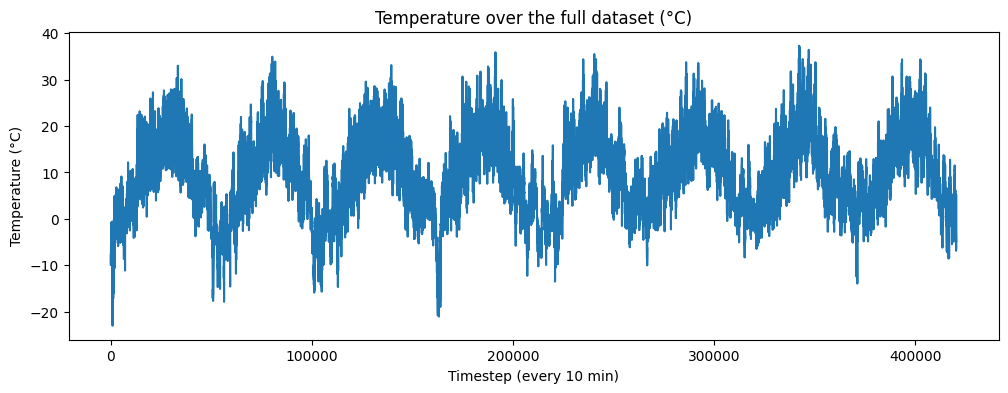

In [ ]:
from matplotlib import pyplot as plt

plt.figure(figsize=(12, 4))
plt.plot(range(len(temperature)), temperature)
plt.title("Temperature over the full dataset (°C)")
plt.xlabel("Timestep (every 10 min)")
plt.ylabel("Temperature (°C)")
plt.show()

You can clearly see the **yearly periodicity** of temperature. The data spans eight years.

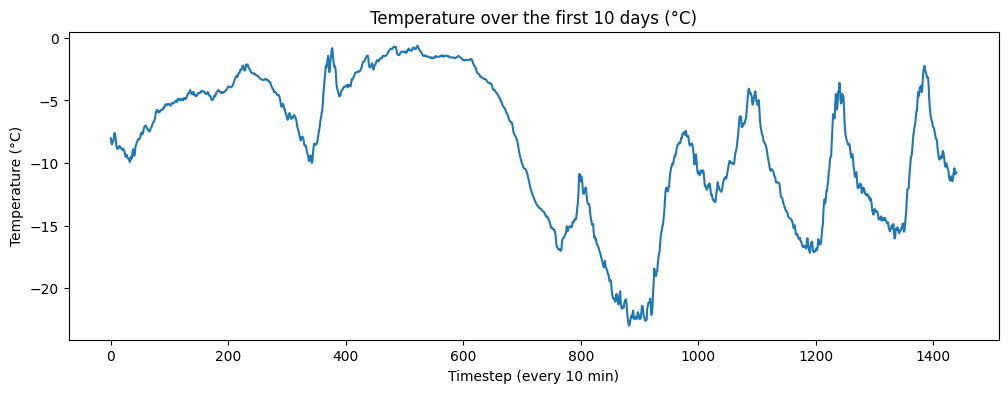

In [ ]:
plt.figure(figsize=(12, 4))
plt.plot(range(1440), temperature[:1440])
plt.title("Temperature over the first 10 days (°C)")
plt.xlabel("Timestep (every 10 min)")
plt.ylabel("Temperature (°C)")
plt.show()

Zooming in reveals **daily periodicity**. Temperature rises during the day and drops at night.
**Important:** When working with timeseries data, validation and test data must be **more recent** than training data. you're predicting the future from the past, not the reverse.

In [ ]:
num_train_samples = int(0.5 * len(raw_data))
num_val_samples = int(0.25 * len(raw_data))
num_test_samples = len(raw_data) - num_train_samples - num_val_samples
print("num_train_samples:", num_train_samples)
print("num_val_samples:", num_val_samples)
print("num_test_samples:", num_test_samples)

num_train_samples: 210225
num_val_samples: 105112
num_test_samples: 105114


### Preparing the Data

**The problem:** Given data covering the previous 5 days (sampled once per hour), predict the temperature 24 hours in the future.

First, we **normalize** each feature independently using the training set's mean and standard deviation. This is critical because the 14 features have very different scales (e.g., atmospheric pressure ~1000 mbar vs. humidity ~3 mmol/mol).

In [ ]:
mean = raw_data[:num_train_samples].mean(axis=0)
raw_data -= mean
std = raw_data[:num_train_samples].std(axis=0)
raw_data /= std

### Understanding `timeseries_dataset_from_array()`

Keras provides a built-in utility for creating sliding-window datasets. Given `data = [0 1 2 3 4 5 6]` and `sequence_length=3`, it generates: `[0 1 2]`, `[1 2 3]`, `[2 3 4]`, etc.

You can also pass a `targets` array, offset by however far into the future you want to predict:

In [ ]:
import numpy as np
import keras

int_sequence = np.arange(10)
dummy_dataset = keras.utils.timeseries_dataset_from_array(
    data=int_sequence[:-3],
    targets=int_sequence[3:],
    sequence_length=3,
    batch_size=2,
)

for inputs, targets in dummy_dataset:
    for i in range(inputs.shape[0]): # iterate through each batch
        print([int(x) for x in inputs[i]], int(targets[i]))

[0, 1, 2] 3
[1, 2, 3] 4
[2, 3, 4] 5
[3, 4, 5] 6
[4, 5, 6] 7


Now let's create our actual datasets with these parameters:

- `sampling_rate = 6`: Sample once per hour (keep 1 out of every 6 data points)
- `sequence_length = 120`: Look back 5 days (120 hours)
- `delay`: Target is the temperature 24 hours after the end of each sequence

In [ ]:
sampling_rate = 6
sequence_length = 120
delay = sampling_rate * (sequence_length + 24 - 1)
batch_size = 256

train_dataset = keras.utils.timeseries_dataset_from_array(
    raw_data[:-delay],
    targets=temperature[delay:],
    sampling_rate=sampling_rate,
    sequence_length=sequence_length,
    shuffle=True,
    batch_size=batch_size,
    start_index=0,
    end_index=num_train_samples,
)

val_dataset = keras.utils.timeseries_dataset_from_array(
    raw_data[:-delay],
    targets=temperature[delay:],
    sampling_rate=sampling_rate,
    sequence_length=sequence_length,
    shuffle=True,
    batch_size=batch_size,
    start_index=num_train_samples,
    end_index=num_train_samples + num_val_samples,
)

test_dataset = keras.utils.timeseries_dataset_from_array(
    raw_data[:-delay],
    targets=temperature[delay:],
    sampling_rate=sampling_rate,
    sequence_length=sequence_length,
    shuffle=True,
    batch_size=batch_size,
    start_index=num_train_samples + num_val_samples,
)

In [ ]:
for samples, targets in train_dataset:
    print("samples shape:", samples.shape)
    print("targets shape:", targets.shape)
    break

samples shape: (256, 120, 14)
targets shape: (256,)


Each batch contains 256 samples, each with 120 hourly timesteps and 14 features → shape `(256, 120, 14)`. Targets are scalar temperatures → shape `(256,)`.

## Establishing Baselines

### Commonsense Baseline

Before using any ML model, we need a **commonsense baseline**. The simplest assumption: the temperature 24 hours from now will be the same as it is right now. This is reasonable because temperature is continuous and periodic.

In [ ]:
def evaluate_naive_method(dataset):
    total_abs_err = 0.0
    samples_seen = 0
    for samples, targets in dataset:
        # Last timestep, temperature column (index 1), un-normalized
        preds = samples[:, -1, 1] * std[1] + mean[1]
        total_abs_err += np.sum(np.abs(preds - targets))
        samples_seen += samples.shape[0]
    return total_abs_err / samples_seen

print(f"Validation MAE: {evaluate_naive_method(val_dataset):.2f}")
print(f"Test MAE: {evaluate_naive_method(test_dataset):.2f}")

Validation MAE: 2.44
Test MAE: 2.62


The commonsense baseline achieves a validation MAE of ~2.44°C and a test MAE of ~2.62°C. Any ML model we build needs to **beat this** to be worth using.

### Dense Network Baseline

Let's see if a simple feedforward network can do better. This model flattens the 5-day window into a single vector and runs it through Dense layers.

In [ ]:
from keras import layers

inputs = keras.Input(shape=(sequence_length, raw_data.shape[-1]))
x = layers.Flatten()(inputs)
x = layers.Dense(16, activation="relu")(x)
outputs = layers.Dense(1)(x)
model = keras.Model(inputs, outputs)

callbacks = [
    keras.callbacks.ModelCheckpoint("jena_dense.keras", save_best_only=True)
]
model.compile(optimizer="adam", loss="mse", metrics=["mae"])
history = model.fit(
    train_dataset,
    epochs=10,
    validation_data=val_dataset,
    callbacks=callbacks,
)

model = keras.models.load_model("jena_dense.keras")
print(f"Test MAE: {model.evaluate(test_dataset)[1]:.2f}")

Epoch 1/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 44s 52ms/step - loss: 11.9163 - mae: 2.6497 - val_loss: 10.5604 - val_mae: 2.5816
Epoch 2/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 41s 49ms/step - loss: 7.9530 - mae: 2.2207 - val_loss: 10.5348 - val_mae: 2.5739
Epoch 3/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 40s 49ms/step - loss: 7.2710 - mae: 2.1194 - val_loss: 10.8827 - val_mae: 2.6224
Epoch 4/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 40s 49ms/step - loss: 6.8852 - mae: 2.0627 - val_loss: 11.4421 - val_mae: 2.6992
Epoch 5/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 40s 49ms/step - loss: 6.5784 - mae: 2.0151 - val_loss: 11.7472 - val_mae: 2.7321
Epoch 6/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 45s 55ms/step - loss: 6.3384 - mae: 1.9791 - val_loss: 11.5551 - val_mae: 2.7019
Epoch 7/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 79s 52ms/step - loss: 6.2014 - mae: 1.9578 - val_loss: 11.8518 - val_mae: 2.7300
Epoch 8/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 42s 51ms/step - loss: 6.0641 - mae: 1.9370 - val_loss: 11.8602 - val_mae: 2.7344
Epoch 9/10
819/819 ━━━━━━━━━━━━

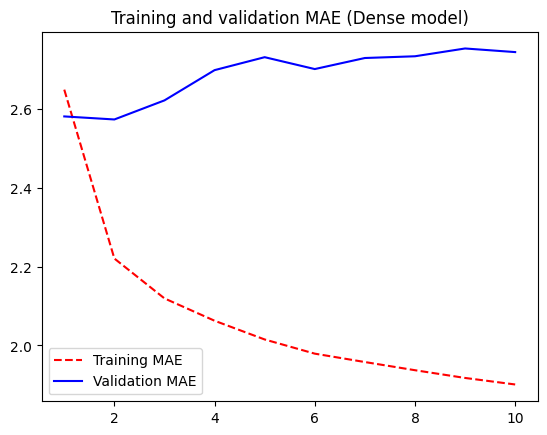

In [ ]:
import matplotlib.pyplot as plt

loss = history.history["mae"]
val_loss = history.history["val_mae"]
epochs = range(1, len(loss) + 1)
plt.figure()
plt.plot(epochs, loss, "r--", label="Training MAE")
plt.plot(epochs, val_loss, "b", label="Validation MAE")
plt.title("Training and validation MAE (Dense model)")
plt.legend()
plt.show()

The Dense model barely matches the commonsense baseline. **Flattening destroys the temporal structure** of the data. The model can't distinguish "what happened 5 days ago" from "what happened 1 hour ago."

### 1D Convolutional Model

Since the data has daily cycles, maybe a convolutional model can pick up on those repeating patterns? `Conv1D` slides a window across the time axis, analogous to how `Conv2D` slides across an image.

In [ ]:
inputs = keras.Input(shape=(sequence_length, raw_data.shape[-1]))
x = layers.Conv1D(8, 24, activation="relu")(inputs)
x = layers.MaxPooling1D(2)(x)
x = layers.Conv1D(8, 12, activation="relu")(x)
x = layers.MaxPooling1D(2)(x)
x = layers.Conv1D(8, 6, activation="relu")(x)
x = layers.GlobalAveragePooling1D()(x)
outputs = layers.Dense(1)(x)
model = keras.Model(inputs, outputs)

callbacks = [
    keras.callbacks.ModelCheckpoint("jena_conv.keras", save_best_only=True)
]
model.compile(optimizer="adam", loss="mse", metrics=["mae"])
history = model.fit(
    train_dataset,
    epochs=10,
    validation_data=val_dataset,
    callbacks=callbacks,
)

model = keras.models.load_model("jena_conv.keras")
print(f"Test MAE: {model.evaluate(test_dataset)[1]:.2f}")

Epoch 1/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 46s 54ms/step - loss: 25.8998 - mae: 3.8755 - val_loss: 15.0962 - val_mae: 3.0660
Epoch 2/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 42s 51ms/step - loss: 14.0675 - mae: 2.9806 - val_loss: 14.6461 - val_mae: 3.0246
Epoch 3/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 42s 50ms/step - loss: 12.6670 - mae: 2.8278 - val_loss: 14.5821 - val_mae: 3.0071
Epoch 4/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 42s 51ms/step - loss: 11.6765 - mae: 2.7142 - val_loss: 15.5219 - val_mae: 3.0791
Epoch 5/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 42s 51ms/step - loss: 11.0525 - mae: 2.6382 - val_loss: 15.2871 - val_mae: 3.0653
Epoch 6/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 43s 52ms/step - loss: 10.6125 - mae: 2.5813 - val_loss: 15.7901 - val_mae: 3.1124
Epoch 7/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 42s 51ms/step - loss: 10.3062 - mae: 2.5414 - val_loss: 16.8256 - val_mae: 3.2029
Epoch 8/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 42s 50ms/step - loss: 9.8964 - mae: 2.4884 - val_loss: 16.5466 - val_mae: 3.1765
Epoch 9/10
819/819 ━━━━━━

<img src="https://deeplearningwithpython.io/images/ch13/conv_model_metrics.fe487977.png" width="500px"/>


The Conv1D model performs even **worse** than the Dense model. Two reasons:

1. Weather data doesn't fully respect **translation invariance**. Morning data has different properties than evening data
2. **Order matters a lot** for forecasting. The recent past is far more informative than data from 5 days ago, and pooling layers destroy this ordering information

---

## Recurrent Neural Networks

Neither the Dense nor the Conv1D approach worked well because both **destroy temporal order** in different ways. We need a model that processes sequences **step-by-step** while maintaining memory of what it has seen.

This is exactly what **Recurrent Neural Networks (RNNs)** do.

### Understanding RNNs

An RNN processes a sequence by iterating through it element-by-element, maintaining a **state** (memory) that gets updated at each timestep.

<img src="https://deeplearningwithpython.io/images/ch13/simplernn.822d53ed.png" width="400px"/>


In pseudocode, an RNN is simply:

```python
state_t = 0                           # Initial state
for input_t in input_sequence:        # Loop over timesteps
    output_t = f(input_t, state_t)    # Combine input with memory
    state_t = output_t                # Update memory
```

The transformation `f` is parameterized by weight matrices `W`, `U`, and a bias `b`:

```
output_t = activation(W@input_t + U@state_t + b)
```

### A Simple RNN in NumPy

To make this concrete, here's a complete RNN forward pass implemented from scratch:

In [ ]:
import numpy as np

timesteps = 100
input_features = 32
output_features = 64

inputs = np.random.random((timesteps, input_features))
hidden_state = np.zeros((output_features,))  # Initial state: all zeros

# Random weight matrices (normally these are learned)
W = np.random.random((output_features, input_features))
U = np.random.random((output_features, output_features))
b = np.random.random((output_features,))

successive_outputs = []
for current_input in inputs:
    # Combine current input with previous state
    hidden_state = np.tanh(W @ current_input + U @ hidden_state + b)
    successive_outputs.append(hidden_state)

full_sequence = np.stack(successive_outputs, axis=0)

# return_sequences=True  -> give me hidden_state at EVERY timestep (for stacking RNNs)
print(f"return_sequences=True:  {full_sequence.shape}")

# return_sequences=False -> give me hidden_state at only the LAST timestep (for final prediction)
print(f"return_sequences=False: {full_sequence[-1].shape}")

return_sequences=True:  (100, 64)
return_sequences=False: (64,)


**In summary, an RNN is a `for` loop** that reuses quantities computed during the previous iteration.

<img src="https://deeplearningwithpython.io/images/ch13/unrolled_lstm_1.d9bee30c.png" width="600px"/>


Each timestep `t` in the output contains information about all timesteps `0` through `t`, the **entire past up to that point**. That's why for many tasks, you only need the last output.

### RNN Layers in Keras

Keras provides `SimpleRNN`, `LSTM`, and `GRU` layers. A key parameter is `return_sequences`:

In [ ]:
num_features = 14
steps = 120
inputs = keras.Input(shape=(steps, num_features))

# return_sequences=False (default): output shape = (batch_size, 16)
outputs = layers.SimpleRNN(16, return_sequences=False)(inputs)
print("return_sequences=False:", outputs.shape)

return_sequences=False: (None, 16)


In [ ]:
inputs = keras.Input(shape=(steps, num_features))

# return_sequences=True: output shape = (batch_size, 120, 16)
outputs = layers.SimpleRNN(16, return_sequences=True)(inputs)
print("return_sequences=True:", outputs.shape)

return_sequences=True: (None, 120, 16)


**Why does this matter?** When you **stack** multiple RNN layers, all intermediate layers must use `return_sequences=True` so the next layer receives a full sequence as input:

In [ ]:
inputs = keras.Input(shape=(steps, num_features))
x = layers.SimpleRNN(16, return_sequences=True)(inputs)   # → (batch, 120, 16)
x = layers.SimpleRNN(16, return_sequences=True)(x)        # → (batch, 120, 16)
outputs = layers.SimpleRNN(16)(x)                          # → (batch, 16)
print("Final output shape:", outputs.shape)

Final output shape: (None, 16)


### The LSTM Layer

In practice, `SimpleRNN` is rarely used because it suffers from the **vanishing gradients problem**: as sequences get longer, the network can't learn long-term dependencies because gradients shrink to near-zero during backpropagation.

The **LSTM** (Long Short-Term Memory) layer, introduced by Hochreiter & Schmidhuber in 1997, solves this by adding a **carry track**, a parallel data flow that allows information to persist across many timesteps, similar to residual connections in deep networks.

<img src="https://deeplearningwithpython.io/images/ch13/unrolled_lstm_2.4145ecdf.png" width="600px"/>


The LSTM uses three learned gates to control the carry track:

- **Forget gate (`f_t`)**: Which parts of the carry to drop
- **Input gate (`i_t`)**: Which new information to add
- **Output gate**: What to output based on the current carry

<img src="https://deeplearningwithpython.io/images/ch13/unrolled_lstm_3.1f68b33f.png" width="600px"/>


You don't need to memorize the exact equations. The key insight is: **LSTM lets past information flow forward unchanged** (via the carry track), which prevents gradients from vanishing.

In [ ]:
# Code to Better Understand How LSTM Works

import numpy as np
from scipy.special import expit as sigmoid  # sigmoid function: squashes values to [0, 1]

timesteps = 100
input_features = 32
output_features = 64

inputs = np.random.random((timesteps, input_features))

# LSTM maintains TWO states (unlike simple RNN which has one):
hidden_state = np.zeros((output_features,))  # Short-term memory, also the output
cell_state = np.zeros((output_features,))    # Long-term memory, flows through time

# LSTM has 4 gates, each with its own weights.
# In a real model these are learned during training.

# Forget gate weights: decides what to REMOVE from long-term memory
W_forget = np.random.random((output_features, input_features))
U_forget = np.random.random((output_features, output_features))
b_forget = np.random.random((output_features,))

# Input gate weights: decides what NEW info to STORE in long-term memory
W_store = np.random.random((output_features, input_features))
U_store = np.random.random((output_features, output_features))
b_store = np.random.random((output_features,))

# Candidate weights: creates NEW candidate values to potentially add to memory
W_candidate = np.random.random((output_features, input_features))
U_candidate = np.random.random((output_features, output_features))
b_candidate = np.random.random((output_features,))

# Output gate weights: decides what to OUTPUT based on current memory
W_output = np.random.random((output_features, input_features))
U_output = np.random.random((output_features, output_features))
b_output = np.random.random((output_features,))

successive_outputs = []
for current_input in inputs:
    # Step 1: FORGET - what should we erase from long-term memory?
    # Values near 0 = forget, near 1 = keep
    what_to_keep = sigmoid(W_forget @ current_input + U_forget @ hidden_state + b_forget)

    # Step 2: INPUT - what new information is worth storing?
    # Values near 0 = ignore, near 1 = store
    worth_storing = sigmoid(W_store @ current_input + U_store @ hidden_state + b_store)

    # Step 3: CANDIDATE - what are the new values we *could* add?
    # tanh gives values in [-1, 1]
    candidate_info = np.tanh(W_candidate @ current_input + U_candidate @ hidden_state + b_candidate)

    # Step 4: UPDATE long-term memory
    # Keep this much of the old memory, plus add this much of the new candidate
    cell_state = what_to_keep * cell_state + worth_storing * candidate_info

    # Step 5: OUTPUT - what part of memory should we output right now?
    what_to_output = sigmoid(W_output @ current_input + U_output @ hidden_state + b_output)

    # Step 6: Compute hidden state, a filtered version of long-term memory
    # This is what the next layer actually sees
    hidden_state = what_to_output * np.tanh(cell_state)

    successive_outputs.append(hidden_state)

full_sequence = np.stack(successive_outputs, axis=0)

# return_sequences=True  -> give me hidden_state at EVERY timestep (for stacking RNNs)
print(f"return_sequences=True:  {full_sequence.shape}")

# return_sequences=False -> give me hidden_state at only the LAST timestep (for final prediction)
print(f"return_sequences=False: {full_sequence[-1].shape}")

return_sequences=True:  (100, 64)
return_sequences=False: (64,)


### LSTM on Jena Temperature Data

Let's try an LSTM on our forecasting problem. This is the first model architecture designed for sequential data:

In [ ]:
inputs = keras.Input(shape=(sequence_length, raw_data.shape[-1]))
x = layers.LSTM(16)(inputs)
outputs = layers.Dense(1)(x)
model = keras.Model(inputs, outputs)

callbacks = [
    keras.callbacks.ModelCheckpoint("jena_lstm.keras", save_best_only=True)
]
model.compile(optimizer="adam", loss="mse", metrics=["mae"])
history = model.fit(
    train_dataset,
    epochs=10,
    validation_data=val_dataset,
    callbacks=callbacks,
)

model = keras.models.load_model("jena_lstm.keras")
print(f"Test MAE: {model.evaluate(test_dataset)[1]:.2f}")

Epoch 1/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 47s 56ms/step - loss: 45.1134 - mae: 4.9582 - val_loss: 17.7302 - val_mae: 3.1322
Epoch 2/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 43s 52ms/step - loss: 14.2797 - mae: 2.8698 - val_loss: 11.4298 - val_mae: 2.5868
Epoch 3/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 42s 51ms/step - loss: 10.9903 - mae: 2.5691 - val_loss: 9.9784 - val_mae: 2.4415
Epoch 4/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 82s 52ms/step - loss: 9.7473 - mae: 2.4250 - val_loss: 9.7845 - val_mae: 2.4290
Epoch 5/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 50s 61ms/step - loss: 9.1960 - mae: 2.3594 - val_loss: 9.5148 - val_mae: 2.3899
Epoch 6/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 43s 52ms/step - loss: 8.7545 - mae: 2.3047 - val_loss: 9.8280 - val_mae: 2.4251
Epoch 7/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 43s 52ms/step - loss: 8.4770 - mae: 2.2717 - val_loss: 9.8396 - val_mae: 2.4333
Epoch 8/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 43s 52ms/step - loss: 8.4756 - mae: 2.2682 - val_loss: 9.2627 - val_mae: 2.3760
Epoch 9/10
819/819 ━━━━━━━━━━━━━━━━

<img src="https://deeplearningwithpython.io/images/ch13/lstm_model_metrics.ae01dd09.png" width="500px"/>


The LSTM achieves a validation MAE of ~2.39°C and test MAE of ~2.55°C. It **beats the commonsense baseline** for the first time! This demonstrates why sequential models are essential for timeseries data.

---

## Improving RNN Performance

Now let's explore three techniques to squeeze more performance out of RNNs:

1. **Recurrent dropout**: Fight overfitting
2. **Stacking RNN layers**: Increase representational power
3. **Bidirectional RNNs**: Process sequences in both directions

### Recurrent Dropout

Standard dropout doesn't work well with RNNs. Applying random dropout masks at each timestep disrupts the temporal learning signal. Instead, RNNs need **the same dropout mask at every timestep** (discovered by Yarin Gal, 2015).

Keras RNN layers have two dropout arguments:
- `dropout`: Dropout rate for the input connections
- `recurrent_dropout`: Dropout rate for the recurrent (state-to-state) connections

With dropout, we can use more units (32 instead of 16) and train for more epochs without overfitting:

In [ ]:
inputs = keras.Input(shape=(sequence_length, raw_data.shape[-1]))
x = layers.LSTM(32, recurrent_dropout=0.25)(inputs)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(1)(x)
model = keras.Model(inputs, outputs)

callbacks = [
    keras.callbacks.ModelCheckpoint(
        "jena_lstm_dropout.keras", save_best_only=True
    )
]
model.compile(optimizer="adam", loss="mse", metrics=["mae"])
history = model.fit(
    train_dataset,
    epochs=50,
    validation_data=val_dataset,
    callbacks=callbacks,
)

<img src="https://deeplearningwithpython.io/images/ch13/lstm_dropout_model_metrics.a624dc88.png" width="500px"/>


With dropout, we're **no longer overfitting** in the first 20 epochs. Validation MAE drops to ~2.27°C, a 7% improvement over the baseline.

### Stacking Recurrent Layers

If you're not overfitting but performance plateaus, try **increasing model capacity** by stacking RNN layers. Remember: intermediate layers need `return_sequences=True`.

Here we use **GRU** layers, a streamlined alternative to LSTM (introduced by Cho et al., 2014):

In [ ]:
inputs = keras.Input(shape=(sequence_length, raw_data.shape[-1]))
x = layers.GRU(32, recurrent_dropout=0.5, return_sequences=True)(inputs)
x = layers.GRU(32, recurrent_dropout=0.5)(x)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(1)(x)
model = keras.Model(inputs, outputs)

callbacks = [
    keras.callbacks.ModelCheckpoint(
        "jena_stacked_gru_dropout.keras", save_best_only=True
    )
]
model.compile(optimizer="adam", loss="mse", metrics=["mae"])
history = model.fit(
    train_dataset,
    epochs=50,
    validation_data=val_dataset,
    callbacks=callbacks,
)
model = keras.models.load_model("jena_stacked_gru_dropout.keras")
print(f"Test MAE: {model.evaluate(test_dataset)[1]:.2f}")

<img src="https://deeplearningwithpython.io/images/ch13/stacked_gru_dropout_model_metrics.5bfbf251.png" width="500px"/>


Test MAE improves to ~2.39°C (8.8% better than the baseline). Stacking helps, but we're seeing **diminishing returns**. more layers won't always mean better results.

### Bidirectional RNNs

A **bidirectional RNN** processes the sequence both forward and backward, then merges the two representations. This can capture patterns that a unidirectional RNN might miss.

<img src="https://deeplearningwithpython.io/images/ch13/bidirectional_rnn.a38aaba4.png" width="500px"/>

In [ ]:
inputs = keras.Input(shape=(sequence_length, raw_data.shape[-1]))
x = layers.Bidirectional(layers.LSTM(16))(inputs)
outputs = layers.Dense(1)(x)
model = keras.Model(inputs, outputs)

model.compile(optimizer="adam", loss="mse", metrics=["mae"])
history = model.fit(
    train_dataset,
    epochs=10,
    validation_data=val_dataset,
)

For **temperature forecasting**, bidirectional LSTMs actually perform **worse** than unidirectional ones. Why? Because the recent past matters much more than the distant past for weather prediction. the reversed-order half adds noise rather than useful information.

However, bidirectional RNNs are **excellent for NLP tasks** (like text classification and machine translation), where a word's importance isn't strongly tied to its position in a sentence. For a while in 2016, bidirectional LSTMs were the state of the art for many NLP tasks. before Transformers took over.

---

## A Note on Markets and Machine Learning

Some readers will want to apply these RNN techniques to **stock market prediction**. However, it's important to understand a fundamental difference:

- **Weather** is a physical system where the past *is* a good predictor of the future. Physics constrains what can happen next
- **Markets** are driven by information arbitrage. Past performance is *not* a reliable predictor of future returns

All trading is fundamentally about having an **information advantage**. Using well-known ML techniques on publicly available data means you have no edge over everyone else doing the same thing.

That said, building an RNN-based stock prediction model is still an excellent **learning exercise**. It forces you to handle real-world timeseries data, deal with normalization, and understand the limitations of your models. Just don't bet your savings on it!

---

## Summary

**Key takeaways from this chapter:**

- Always establish a **commonsense baseline** before building ML models. If you can't beat a simple heuristic, your model isn't adding value.

- Try **simple models first** (Dense, Conv1D) before expensive ones (RNNs). Sometimes simpler is better, and when it's not, you know why.

- For data where **temporal order matters**, RNNs are a natural fit. The key RNN layers in Keras are **LSTM** and **GRU**.

- Use **recurrent dropout** (`recurrent_dropout` parameter) to regularize RNNs. Standard dropout doesn't work well because it disrupts the temporal error signal.

- **Stacking** RNN layers increases representational power, but watch for diminishing returns.

- **Bidirectional RNNs** work well for NLP but not for tasks where the recent past is more important than the distant past (like weather forecasting).

---

**Performance on Jena temperature forecasting (Test MAE):**

| Approach | Test MAE (°C) | vs. Baseline |
|----------|--------------|-------------|
| Commonsense baseline | ~2.62 | - |
| Dense network | ~2.6+ | ≈ 0% |
| 1D ConvNet | ~2.9 | worse |
| LSTM (16 units) | ~2.55 | ~2.7% |
| LSTM + dropout (32 units) | ~2.45 | ~6.5% |
| Stacked GRU + dropout | ~2.39 | ~8.8% |

---

**Up next:** In the following chapters, we will explore the **Transformer** architecture, which has largely replaced RNNs for many sequence tasks, including NLP and even some timeseries applications.